In [1]:
# STEP 1: IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set(style="whitegrid")

In [3]:
# STEP 2: LOAD DATASET
# -----------------------------
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [4]:
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())



First 5 Rows:
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2   

In [5]:
# DATA CLEANING
# ============================================================

# -----------------------------
# STEP 4: CHECK MISSING VALUES
# -----------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())



Missing Values:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Missing Values After Cleaning:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [6]:
# STEP 5: REMOVE DUPLICATES
# -----------------------------
print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)


Duplicate Rows: 0
Dataset Shape After Removing Duplicates:
(1200, 13)


In [17]:
# -----------------------------
# STEP 6: HANDLE OUTLIERS
# -----------------------------
# Using IQR Method

def remove_outliers(data, columns):

    for col in columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        data = data[
            (data[col] >= lower) &
            (data[col] <= upper)
        ]

    return data

df = remove_outliers(df, numeric_cols)

print("\nDATASET SHAPE AFTER CLEANING")
print(df.shape)



DATASET SHAPE AFTER CLEANING
(1169, 13)


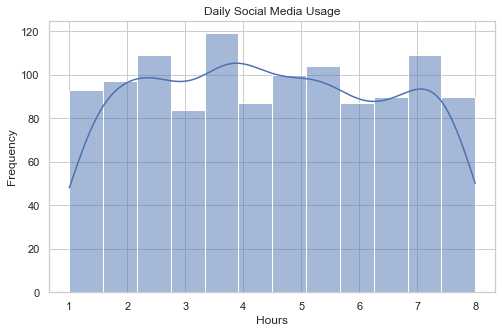

In [18]:
# DATA VISUALIZATION
# ============================================================

# 1. SOCIAL MEDIA USAGE DISTRIBUTION
# -----------------------------
plt.figure(figsize=(8,5))

sns.histplot(df['daily_social_media_hours'], kde=True)

plt.title("Daily Social Media Usage")

plt.xlabel("Hours")

plt.ylabel("Frequency")

plt.show()

plt.show()

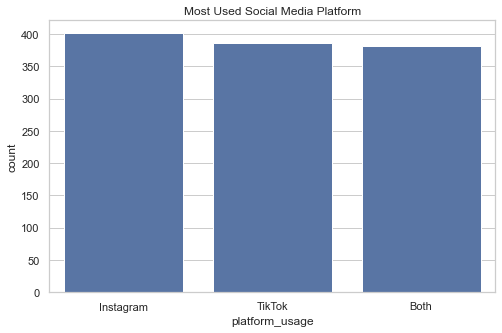

In [19]:
# 2. PLATFORM USAGE COUNT
# -----------------------------
plt.figure(figsize=(8,5))

sns.countplot(
    x='platform_usage',
    data=df
)

plt.title("Most Used Social Media Platform")

plt.show()


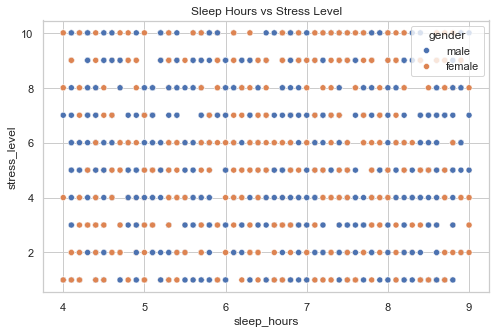

In [21]:
#SLEEP HOURS VS STRESS LEVEL
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='sleep_hours',
    y='stress_level',
    hue='gender',
    data=df
)

plt.title("Sleep Hours vs Stress Level")

plt.show()


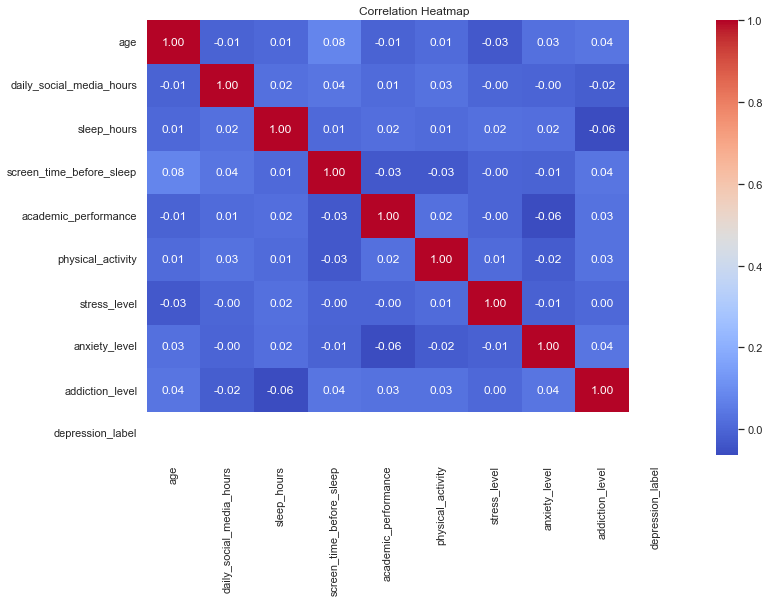

In [11]:
# STEP 10: CORRELATION HEATMAP
# -----------------------------
plt.figure(figsize=(12,8))

correlation = df[numeric_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

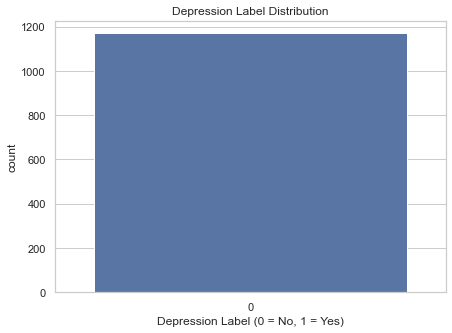

In [12]:
# STEP 11: DEPRESSION ANALYSIS
# -----------------------------
plt.figure(figsize=(7,5))

sns.countplot(
    x='depression_label',
    data=df
)

plt.title("Depression Label Distribution")
plt.xlabel("Depression Label (0 = No, 1 = Yes)")

plt.show()


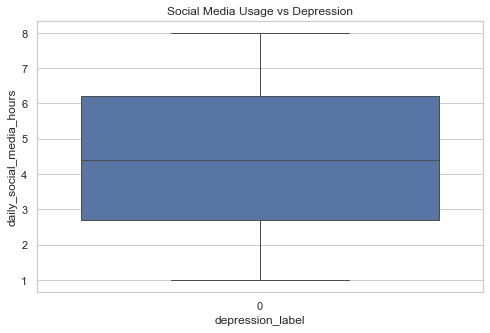

In [13]:
# STEP 12: SOCIAL MEDIA HOURS VS DEPRESSION
# -----------------------------
plt.figure(figsize=(8,5))

sns.boxplot(
    x='depression_label',
    y='daily_social_media_hours',
    data=df
)

plt.title("Social Media Usage vs Depression")

plt.show()


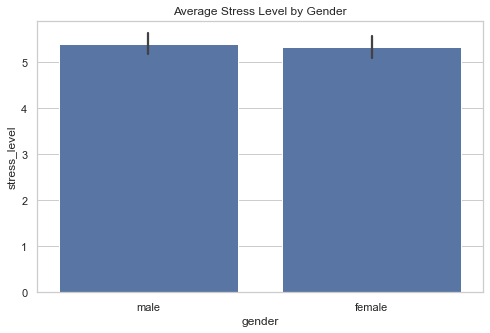

In [14]:
# STRESS LEVEL BY GENDER
# -----------------------------
plt.figure(figsize=(8,5))

sns.barplot(
    x='gender',
    y='stress_level',
    data=df
)

plt.title("Average Stress Level by Gender")

plt.show()

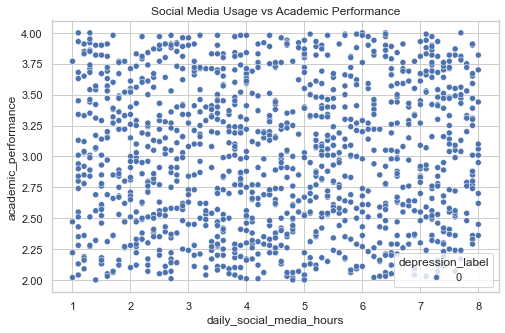

In [15]:
#  ACADEMIC PERFORMANCE ANALYSIS
# -----------------------------
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='daily_social_media_hours',
    y='academic_performance',
    hue='depression_label',
    data=df
)

plt.title("Social Media Usage vs Academic Performance")

plt.show()

In [25]:
print("\n================ KEY INSIGHTS ================")

print(
    f"\nAverage Daily Social Media Usage: "
    f"{df['daily_social_media_hours'].mean():.2f} hours"
)

print(
    f"Average Sleep Hours: "
    f"{df['sleep_hours'].mean():.2f} hours"
)

print(
    f"Average Stress Level: "
    f"{df['stress_level'].mean():.2f}"
)

print(
    f"Average Anxiety Level: "
    f"{df['anxiety_level'].mean():.2f}"
)

print("\nPossible Findings:")

print("- Higher social media usage may increase stress.")
print("- Less sleep may relate to higher anxiety.")
print("- Addiction level may affect academic performance.")
print("- Depression levels may rise with excessive screen time.")

# ============================================================
# SAVE CLEANED DATASET
# ============================================================

df.to_csv("cleaned_social_media_dataset.csv", index=False)

print("\nCLEANED DATASET SAVED SUCCESSFULLY")


================ KEY INSIGHTS ================

Average Daily Social Media Usage: 4.48 hours
Average Sleep Hours: 6.49 hours
Average Stress Level: 5.37
Average Anxiety Level: 5.56

Possible Findings:
- Higher social media usage may increase stress.
- Less sleep may relate to higher anxiety.
- Addiction level may affect academic performance.
- Depression levels may rise with excessive screen time.

CLEANED DATASET SAVED SUCCESSFULLY
